# KNN PROJECT

A basic K-Nearest Neighbors classification workflow using the Iris dataset.

In [23]:
# Import Libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, ConfusionMatrixDisplay

## Load and Explore the Dataset

In [24]:
# Load the Iris dataset
iris = load_iris()

X = pd.DataFrame(iris.data, columns=iris.feature_names)
y = pd.Series(iris.target, name="target")

display(X.head())
display(y.head())

print("Dataset shape:", X.shape)
print("Class distribution:")
print(y.value_counts().sort_index())
print("Class names:", iris.target_names)

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm)
0,5.1,3.5,1.4,0.2
1,4.9,3.0,1.4,0.2
2,4.7,3.2,1.3,0.2
3,4.6,3.1,1.5,0.2
4,5.0,3.6,1.4,0.2


,target
0,0
1,0
2,0
3,0
4,0


Dataset shape: (150, 4)
Class distribution:
target
0    50
1    50
2    50
Name: count, dtype: int64
Class names: ['setosa' 'versicolor' 'virginica']


## Split Data into Training and Testing Sets

In [25]:
# Split the data
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("Training samples:", X_train.shape[0])
print("Testing samples:", X_test.shape[0])

Training samples: 120
Testing samples: 30


## Scale the Features

In [26]:
# Standardize feature values
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("Features scaled successfully.")

Features scaled successfully.


## Train the KNN Classifier

In [27]:
# Create and train the KNN model
knn = KNeighborsClassifier(n_neighbors=5)
knn.fit(X_train_scaled, y_train)

y_pred = knn.predict(X_test_scaled)

print("Predictions:", y_pred)

Predictions: [0 2 1 1 0 1 0 0 2 1 2 2 2 1 0 0 0 1 1 1 0 2 1 1 2 1 1 0 2 0]


## Evaluate Model Performance

Accuracy: 0.9333333333333333

Classification Report:
              precision    recall  f1-score   support

      setosa       1.00      1.00      1.00        10
  versicolor       0.83      1.00      0.91        10
   virginica       1.00      0.80      0.89        10

    accuracy                           0.93        30
   macro avg       0.94      0.93      0.93        30
weighted avg       0.94      0.93      0.93        30

Confusion Matrix:
[[10  0  0]
 [ 0 10  0]
 [ 0  2  8]]


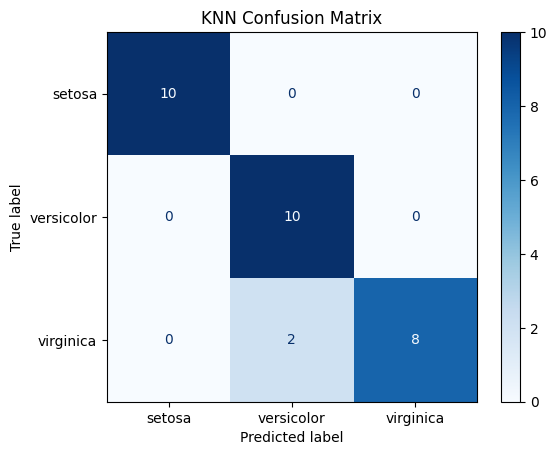

In [28]:
# Evaluate the model
accuracy = accuracy_score(y_test, y_pred)

print("Accuracy:", accuracy)
print("\nClassification Report:")
print(classification_report(y_test, y_pred, target_names=iris.target_names))

cm = confusion_matrix(y_test, y_pred)
print("Confusion Matrix:")
print(cm)

display = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=iris.target_names
)
display.plot(cmap="Blues")
plt.title("KNN Confusion Matrix")
plt.show()

## Make a Sample Prediction

In [29]:
# Predict the class of a new sample
new_sample = np.array([[5.1, 3.5, 1.4, 0.2]])

new_sample_scaled = scaler.transform(new_sample)
prediction = knn.predict(new_sample_scaled)

print("Predicted class:", iris.target_names[prediction[0]])

Predicted class: setosa
